In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch

%matplotlib inline

In [2]:
df = pd.read_csv("seismic_activity_svm.csv")

In [3]:
df.tail()

,underground_wave_energy,vibration_axis_variation,seismic_event_detected
395,-4.170824,-2.757576,1
396,-4.130115,-2.818182,1
397,-4.088102,-2.878788,1
398,-4.044745,-2.939394,1
399,-4.000000,-3.000000,1


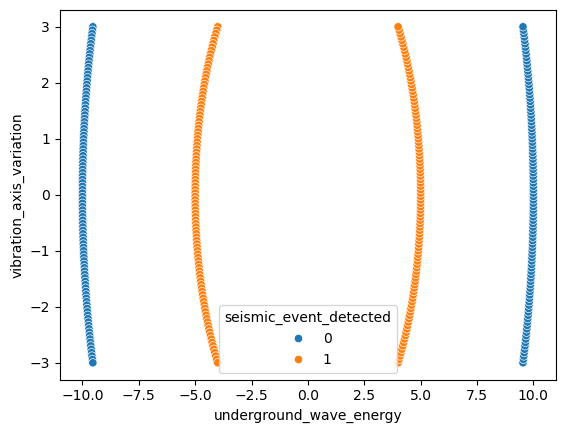

In [4]:
sns.scatterplot(x="underground_wave_energy",y="vibration_axis_variation", hue= "seismic_event_detected", data=df)
plt.show()

In [5]:
# non-linear

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   underground_wave_energy   400 non-null    float64
 1   vibration_axis_variation  400 non-null    float64
 2   seismic_event_detected    400 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 9.5 KB


In [7]:
df.describe()

,underground_wave_energy,vibration_axis_variation,seismic_event_detected
count,400.000000,4.000000e+02,400.000000
mean,0.000000,8.881784e-18,0.500000
std,7.719350,1.751650e+00,0.500626
min,-9.999954,-3.000000e+00,0.000000
25%,-6.134779,-1.500000e+00,0.000000
50%,0.000000,0.000000e+00,0.500000
75%,6.134779,1.500000e+00,1.000000
max,9.999954,3.000000e+00,1.000000


In [8]:
df.isnull().sum()

underground_wave_energy     0
vibration_axis_variation    0
seismic_event_detected      0
dtype: int64

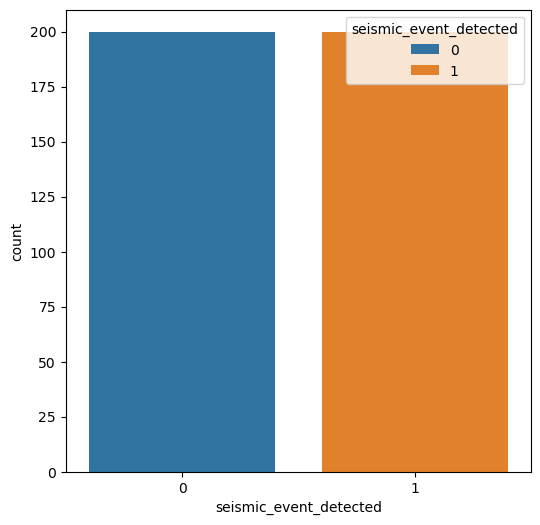

In [9]:
plt.figure(figsize=(6,6))
sns.countplot(x="seismic_event_detected", data=df, hue="seismic_event_detected")
plt.show()

In [10]:
X = df[["underground_wave_energy","vibration_axis_variation"]].values
y = df["seismic_event_detected"].values

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [12]:
X_train.shape , X_test.shape

((320, 2), (80, 2))

In [13]:
y_train.shape, y_test.shape

((320,), (80,))

In [14]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)
y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)

In [15]:
from torch import nn

class Model(nn.Module):
    def __init__(self):
        super().__init__()

        self.layer1 = nn.Linear(in_features=2, out_features=10, bias=True)
        self.relu = nn.ReLU()
        self.layer2 = nn.Linear(in_features=10, out_features=1, bias=True)

    def forward(self, x:torch.tensor) -> torch.tensor:
        return self.layer2(self.relu(self.layer1(x)))

In [21]:
model = Model()

loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(params=model.parameters(), lr=0.001)

In [22]:
def calculate_accuracy(y_pred,y_test):
    correct = torch.eq(y_pred, y_test).sum()
    acc = (correct/len(y_test)) * 100
    return acc.item()

In [23]:
torch.manual_seed(42)
epochs = 500

for epoch in range(epochs):
    model.train()
    y_logits = model(X_train)
    y_train_pred = torch.round(torch.sigmoid(y_logits))
    train_loss = loss_fn(y_logits, y_train)
    train_acc = calculate_accuracy(y_train_pred, y_train)

    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()

    model.eval()
    with torch.inference_mode():
        y_test_logits = model(X_test)
        y_test_pred = torch.round(torch.sigmoid(y_test_logits))
        test_loss = loss_fn(y_test_logits, y_test)
        test_acc = calculate_accuracy(y_test_pred, y_test)

    if epoch % 20 == 0:
        print(f"Epoch: {epoch}, Train Accuracy: {train_acc}, Test Accuracy: {test_acc}")

Epoch: 0, Train Accuracy: 52.8125, Test Accuracy: 55.0
Epoch: 20, Train Accuracy: 56.875003814697266, Test Accuracy: 58.749996185302734
Epoch: 40, Train Accuracy: 52.499996185302734, Test Accuracy: 48.75
Epoch: 60, Train Accuracy: 48.4375, Test Accuracy: 43.75
Epoch: 80, Train Accuracy: 44.375, Test Accuracy: 40.0
Epoch: 100, Train Accuracy: 46.875, Test Accuracy: 46.25
Epoch: 120, Train Accuracy: 51.875, Test Accuracy: 57.5
Epoch: 140, Train Accuracy: 55.0, Test Accuracy: 60.000003814697266
Epoch: 160, Train Accuracy: 54.375, Test Accuracy: 60.000003814697266
Epoch: 180, Train Accuracy: 55.624996185302734, Test Accuracy: 60.000003814697266
Epoch: 200, Train Accuracy: 59.6875, Test Accuracy: 60.000003814697266
Epoch: 220, Train Accuracy: 62.8125, Test Accuracy: 62.5
Epoch: 240, Train Accuracy: 65.0, Test Accuracy: 65.0
Epoch: 260, Train Accuracy: 66.875, Test Accuracy: 66.25
Epoch: 280, Train Accuracy: 68.125, Test Accuracy: 68.75
Epoch: 300, Train Accuracy: 69.6875, Test Accuracy: 70.